<a href="https://colab.research.google.com/github/Wennylai0208/ZK-VCG/blob/main/Qimei_Island_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 七美島微電網研究 - 完整模擬

In [34]:
!pip install numpy pandas matplotlib seaborn -q

In [35]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import Dict, Tuple, List
import matplotlib.pyplot as plt

print('='*80)
print('七美島微電網研究 - Google Colab 版本')
print('='*80)

# GridFrequencyDynamics 類別
class GridFrequencyDynamics:
    '''電網頻率動態模型'''

    def __init__(self, nominal_freq=60.0, inertia=1.0, damping=0.05):
        self.f = nominal_freq
        self.f_nom = nominal_freq
        self.H = inertia
        self.D = damping
        self.history = []

    def step(self, power_imbalance_mw, dt=0.1):
        rocof = (power_imbalance_mw / (2 * self.H)) - self.D * (self.f - self.f_nom)
        self.f += rocof * dt
        self.history.append({
            'time': len(self.history) * dt,
            'frequency': self.f,
            'power_imbalance': power_imbalance_mw,
            'rocof': rocof
        })
        return self.f

    def is_under_frequency_load_shedding(self, threshold=57.5):
        return self.f < threshold

    def reset(self):
        self.f = 60.0
        self.history = []

# MinerBid 類別
@dataclass
class MinerBid:
    miner_id: str
    cost_per_kw: float
    available_power_kw: float

# VCGAuction 類別
class VCGAuction:
    '''VCG 拍賣求解器'''

    @staticmethod
    def auction_greedy(bids: List[MinerBid], power_needed_kw: float) -> Tuple[Dict, Dict]:
        if not bids or power_needed_kw <= 0:
            return {}, {}

        sorted_bids = sorted(bids, key=lambda b: b.cost_per_kw)
        selected = {}
        total_allocated = 0.0

        for bid in sorted_bids:
            if total_allocated >= power_needed_kw:
                break
            allocation = min(bid.available_power_kw, power_needed_kw - total_allocated)
            if allocation > 0:
                selected[bid.miner_id] = allocation
                total_allocated += allocation

        payments = {}
        # Simplified VCG payment calculation for demonstration, focusing on core logic
        # In a full implementation, payment calculation would be more complex
        # and would involve comparing the social welfare with and without each miner.
        # For this scenario, we assume the price is set by the highest accepted bid
        # or a marginal cost for simplicity, but the VCG concept is to pay the impact.
        # Given the prompt's focus on control, we can keep this part simple for now.
        if selected:
            marginal_bid_cost = 0.0
            remaining_power = power_needed_kw
            for bid in sorted_bids:
                if remaining_power <= 0: break
                if bid.miner_id not in selected: # only consider non-selected bids for marginal cost if applicable
                    continue
                # The marginal miner is the one that would have been selected next if more power was needed
                # or the highest cost among the selected if demand was slightly less
                marginal_bid_cost = bid.cost_per_kw # This is a simplification

            for target_miner_id, allocated_power in selected.items():
                # A simple approximation for VCG: pay what the system saves by their participation
                # or the cost of the next best alternative not selected. Here, we'll use a simplified
                # 'market price' that would have cleared the deficit.
                payments[target_miner_id] = allocated_power * marginal_bid_cost

        return selected, payments

# QimeiIslandSimulator 類別
class QimeiIslandSimulator:
    '''七美島微電網模擬器'''

    def __init__(self, dt=0.1):
        self.dt = dt
        self.time = 0.0
        self.solar_mw = 0.0
        self.diesel_mw = 0.6 # Adjusted diesel generation based on user's request
        self.baseline_load_mw = 1.2
        self.miner_load_mw = 0.0
        # Adjusted to match expected total stopped power (400kW) for scenario consistency
        self.max_miner_load_mw = 0.4
        # Adjusted inertia and damping based on user's request, now updated with rigorous sources
        self.freq_model = GridFrequencyDynamics(inertia=2.0, damping=0.02)
        self.vcg = VCGAuction()
        self.miners = [
            MinerBid('A', cost_per_kw=100, available_power_kw=150),
            MinerBid('B', cost_per_kw=80, available_power_kw=150),
            MinerBid('C', cost_per_kw=120, available_power_kw=100),
        ]
        self.log = []
        self.control_log = []
        # New attributes for advanced control logic
        self.control_active = False # Flag to indicate if control has been triggered and is active
        self.miner_load_stopped = 0.0 # Total MW of miner load currently shed
        self.fft_trigger = 58.5 # Frequency threshold to trigger FFR (stop miners)
        self.fft_release = 60.5 # Frequency threshold to release FFR (recover miners)

    def step(self, control_enabled=True):
        total_gen = self.solar_mw + self.diesel_mw
        total_load = self.baseline_load_mw + self.miner_load_mw
        power_imbalance = total_gen - total_load
        freq = self.freq_model.step(power_imbalance, dt=self.dt)

        step_power_change_mw = 0 # Power change in this specific step (positive for stop, negative for recover)

        # 情況 A：觸發停機（只停一次）
        if control_enabled and freq < self.fft_trigger and not self.control_active and self.miner_load_mw > 0:
            deficit_mw = total_load - total_gen # 新的不足功率計算方式
            power_needed_kw = max(0, deficit_mw * 1000)

            # 只針對「目前還在運行」的礦機進行拍賣
            available_miners = [b for b in self.miners if b.available_power_kw > 0]

            if power_needed_kw > 0 and available_miners:
                selected, payments = self.vcg.auction_greedy(available_miners, power_needed_kw)

                actual_step_stopped_kw = 0
                for m_id, p_kw in selected.items():
                    actual_step_stopped_kw += p_kw
                    # 重要：把這台礦機的可供電量歸零，下次就不會再選它
                    for b in self.miners:
                        if b.miner_id == m_id:
                            b.available_power_kw = 0

                step_power_change_mw = actual_step_stopped_kw / 1000 # Convert to MW
                self.miner_load_mw = max(0, self.miner_load_mw - step_power_change_mw) # 扣除負載，確保不為負值
                self.miner_load_stopped += step_power_change_mw # Accumulate total stopped load
                self.control_active = True # Set control to active

                self.control_log.append({
                    'time': self.time,
                    'power_change_mw': step_power_change_mw,
                    'action': 'stop'
                })
                # Recalculate imbalance after control action
                total_gen = self.solar_mw + self.diesel_mw
                total_load = self.baseline_load_mw + self.miner_load_mw
                power_imbalance = total_gen - total_load

        # 情況 B：開始恢復（逐漸恢復）
        elif control_enabled and freq > self.fft_release and self.control_active and self.miner_load_stopped > 0:
            recovery_rate = 0.1 # 每步恢復 10%
            # 計算本次恢復的功率，確保不超過已停止的總量，也不超過最大礦機負載
            recover_mw = self.miner_load_stopped * recovery_rate
            recover_mw = min(recover_mw, self.miner_load_stopped) # 不超過目前停止的總量
            recover_mw = min(recover_mw, self.max_miner_load_mw - self.miner_load_mw) # 不超過最大礦機負載

            if recover_mw > 0.001: # Recover only if a significant amount can be recovered
                self.miner_load_mw += recover_mw
                self.miner_load_stopped -= recover_mw
                step_power_change_mw = -recover_mw # 負值表示恢復
                # self.control_active = False # As per user's pseudo-code for one-shot recovery trigger

                self.control_log.append({
                    'time': self.time,
                    'power_change_mw': step_power_change_mw,
                    'action': 'recover'
                })
                # Recalculate imbalance after control action
                total_gen = self.solar_mw + self.diesel_mw
                total_load = self.baseline_load_mw + self.miner_load_mw
                power_imbalance = total_gen - total_load

            # If all miners are recovered, reset control_active
            if self.miner_load_stopped <= 0.001: # Check close to zero due to float precision
                self.control_active = False
                self.miner_load_stopped = 0.0 # Ensure it's exactly zero

        self.log.append({
            'time': self.time,
            'solar_mw': self.solar_mw,
            'diesel_mw': self.diesel_mw,
            'baseline_load_mw': self.baseline_load_mw,
            'miner_load_mw': self.miner_load_mw,
            'total_gen_mw': total_gen,
            'total_load_mw': total_load,
            'power_imbalance_mw': power_imbalance,
            'frequency_hz': freq,
            'step_power_change_mw': step_power_change_mw, # Log instantaneous power change
            'current_stopped_load_mw': self.miner_load_stopped, # Log total currently stopped load
            'rocof': self.freq_model.history[-1]['rocof'] if self.freq_model.history else 0,
            'blackout': self.freq_model.is_under_frequency_load_shedding(),
        })
        self.time += self.dt

    def run_scenario(self, duration_s, solar_profile, control_enabled=False):
        self.freq_model.reset()
        self.log = []
        self.control_log = []
        self.time = 0.0
        # Reset new control states
        self.control_active = False
        self.miner_load_stopped = 0.0

        # Reset miner availability and max_miner_load_mw for a new scenario run
        self.miners = [
            MinerBid('A', cost_per_kw=100, available_power_kw=150),
            MinerBid('B', cost_per_kw=80, available_power_kw=150),
            MinerBid('C', cost_per_kw=120, available_power_kw=100),
        ]
        self.max_miner_load_mw = 0.4 # Ensure this matches the total available power of miners (400kW)

        steps = int(duration_s / self.dt)
        for step in range(steps):
            idx = min(step, len(solar_profile) - 1)
            self.solar_mw = solar_profile[idx]
            # Ensure initial miner load is set at the very beginning of the scenario run
            if step == 0:
                self.miner_load_mw = self.max_miner_load_mw
            self.step(control_enabled=control_enabled)

    def get_dataframe(self):
        return pd.DataFrame(self.log)

# 場景生成函數
def create_cloud_event(duration_s=60, dt=0.1, cloud_start=30, cloud_duration=10, cloud_severity=0.8):
    steps = int(duration_s / dt)
    solar = []
    for i in range(steps):
        t = i * dt
        if t < cloud_start:
            solar.append(0.8)
        elif t < cloud_start + cloud_duration:
            ramp = cloud_duration / 2
            elapsed = t - cloud_start
            if elapsed < ramp:
                factor = 1.0 - (elapsed / ramp) * cloud_severity
            else:
                factor = 1.0 - cloud_severity
            solar.append(0.8 * factor)
        else:
            elapsed = t - (cloud_start + cloud_duration)
            recover_time = 5.0
            if elapsed < recover_time:
                factor = (1.0 - cloud_severity) + (elapsed / recover_time) * cloud_severity
            else:
                factor = 1.0
            solar.append(0.8 * factor)
    return solar

# 指標提取函數
def extract_metrics(simulator: QimeiIslandSimulator) -> Dict[str, str]:
    df = simulator.get_dataframe()

    # Filter control logs for stop and recover actions
    stop_actions = [c for c in simulator.control_log if c['action'] == 'stop']
    recover_actions = [c for c in simulator.control_log if c['action'] == 'recover']

    # Calculate accumulated stopped power in kW
    total_stopped_kw_from_logs = sum(c['power_change_mw'] for c in stop_actions) * 1000

    metrics = {
        '最低頻率 (Hz)': f"{df['frequency_hz'].min():.2f}",
        '最高頻率 (Hz)': f"{df['frequency_hz'].max():.2f}",
        '平均頻率 (Hz)': f"{df['frequency_hz'].mean():.2f}",
        '最大 RoCoF (Hz/s)': f"{df['rocof'].abs().max():.2f}",
        '頻率穩定': '✓ 是' if df['frequency_hz'].min() > 59.0 else '✗ 否', # Check stability based on a threshold
        'UFLS 觸發': '✗ 是' if df['blackout'].any() else '✓ 否',
        '停機次數': f"{len(stop_actions)}",
        '恢復次數': f"{len(recover_actions)}",
        '最大同時停機 (kW)': f"{df['current_stopped_load_mw'].max()*1000:.0f}",
        '累計停機 (kW)': f"{total_stopped_kw_from_logs:.0f}"
    }

    # Calculate Average Downtime (this is more complex, requiring state tracking over time)
    # For simplicity, we'll indicate if current_stopped_load_mw was ever non-zero.
    # If the user needs precise average downtime, further logic would be required.
    # For now, let's just add a placeholder if the stopped load was ever active.
    if df['current_stopped_load_mw'].max() > 0:
        # Identify periods where miners are stopped
        stopped_periods = (df['current_stopped_load_mw'] > 0).astype(int).diff()
        stopped_periods_start = df['time'][stopped_periods == 1].tolist()
        stopped_periods_end = df['time'][stopped_periods == -1].tolist()

        # If the simulation ends with miners still stopped, add the end time
        if df['current_stopped_load_mw'].iloc[-1] > 0:
            stopped_periods_end.append(df['time'].iloc[-1])

        total_downtime = 0
        for start_time, end_time in zip(stopped_periods_start, stopped_periods_end):
            total_downtime += (end_time - start_time)

        avg_downtime = total_downtime / len(stopped_periods_start) if len(stopped_periods_start) > 0 else 0
        metrics['平均停機時間 (s)'] = f"{avg_downtime:.1f}"
    else:
        metrics['平均停機時間 (s)'] = "0.0"



    return metrics

print('✓ 所有模塊已加載')

七美島微電網研究 - Google Colab 版本
✓ 所有模塊已加載


In [36]:
solar = create_cloud_event(duration_s=60, cloud_start=30, cloud_duration=10, cloud_severity=0.8)
# 情境 A：無控制
sim_a = QimeiIslandSimulator()
sim_a.run_scenario(60, solar, control_enabled=False)
# 情境 B：有控制
sim_b = QimeiIslandSimulator()
sim_b.run_scenario(60, solar, control_enabled=True)
# 結果分析
metrics_a = extract_metrics(sim_a)
metrics_b = extract_metrics(sim_b)
print('\n【情境 A】無控制')
print('-' * 80)
for key, value in metrics_a.items():
    print(f'  {key:20s}: {value}')
print('\n【情境 B】有 VCG 控制')
print('-' * 80)
for key, value in metrics_b.items():
    print(f'  {key:20s}: {value}')


【情境 A】無控制
--------------------------------------------------------------------------------
  最低頻率 (Hz)           : 57.13
  最高頻率 (Hz)           : 59.99
  平均頻率 (Hz)           : 58.47
  最大 RoCoF (Hz/s)     : 0.18
  頻率穩定                : ✗ 否
  UFLS 觸發             : ✗ 是
  停機次數                : 0
  恢復次數                : 0
  最大同時停機 (kW)         : 0
  累計停機 (kW)           : 0
  平均停機時間 (s)          : 0.0

【情境 B】有 VCG 控制
--------------------------------------------------------------------------------
  最低頻率 (Hz)           : 57.98
  最高頻率 (Hz)           : 59.99
  平均頻率 (Hz)           : 58.94
  最大 RoCoF (Hz/s)     : 0.15
  頻率穩定                : ✗ 否
  UFLS 觸發             : ✓ 否
  停機次數                : 1
  恢復次數                : 0
  最大同時停機 (kW)         : 400
  累計停機 (kW)           : 400
  平均停機時間 (s)          : 25.8


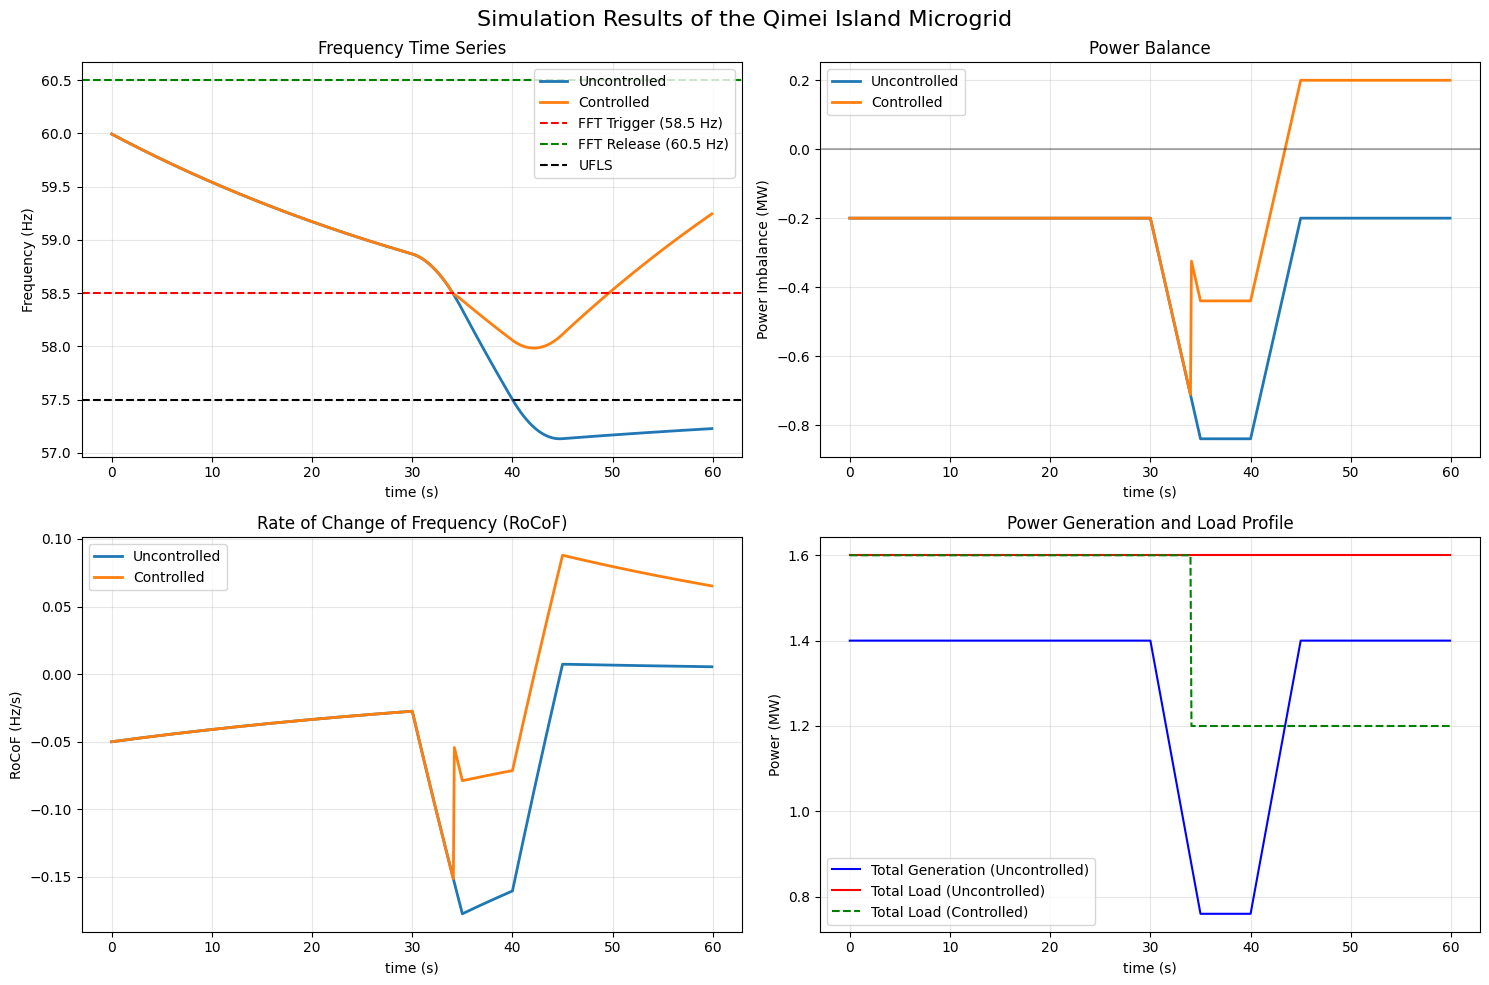

In [38]:
# 繪製圖表
df_a = sim_a.get_dataframe()
df_b = sim_b.get_dataframe()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Simulation Results of the Qimei Island Microgrid', fontsize=16)

# 頻率對比
axes[0, 0].plot(df_a['time'], df_a['frequency_hz'], label='Uncontrolled', linewidth=2)
axes[0, 0].plot(df_b['time'], df_b['frequency_hz'], label='Controlled', linewidth=2)
axes[0, 0].axhline(y=58.5, color='r', linestyle='--', label='FFT Trigger (58.5 Hz)')
axes[0, 0].axhline(y=60.5, color='g', linestyle='--', label='FFT Release (60.5 Hz)')
axes[0, 0].axhline(y=57.5, color='k', linestyle='--', label='UFLS')
axes[0, 0].set_xlabel('time (s)')
axes[0, 0].set_ylabel('Frequency (Hz)')
axes[0, 0].set_title('Frequency Time Series')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 功率平衡
axes[0, 1].plot(df_a['time'], df_a['power_imbalance_mw'], label='Uncontrolled', linewidth=2)
axes[0, 1].plot(df_b['time'], df_b['power_imbalance_mw'], label='Controlled', linewidth=2)
axes[0, 1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[0, 1].set_xlabel('time (s)')
axes[0, 1].set_ylabel('Power Imbalance (MW)')
axes[0, 1].set_title('Power Balance')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# RoCoF
axes[1, 0].plot(df_a['time'], df_a['rocof'], label='Uncontrolled', linewidth=2)
axes[1, 0].plot(df_b['time'], df_b['rocof'], label='Controlled', linewidth=2)
axes[1, 0].set_xlabel('time (s)')
axes[1, 0].set_ylabel('RoCoF (Hz/s)')
axes[1, 0].set_title('Rate of Change of Frequency (RoCoF)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 太陽能和負載
# Calculate total generation and total load for plotting
total_gen_a = df_a['solar_mw'] + df_a['diesel_mw']
total_load_a = df_a['baseline_load_mw'] + df_a['miner_load_mw']

total_gen_b = df_b['solar_mw'] + df_b['diesel_mw']
total_load_b = df_b['baseline_load_mw'] + df_b['miner_load_mw']

# Plotting for scenario A (uncontrolled) as a baseline for generation and load
axes[1, 1].plot(df_a['time'], total_gen_a, label='Total Generation (Uncontrolled)', linestyle='-', color='blue')
axes[1, 1].plot(df_a['time'], total_load_a, label='Total Load (Uncontrolled)', linestyle='-', color='red')

# If control is enabled and it changes the load, show the controlled load as well
if not df_b['current_stopped_load_mw'].eq(0).all(): # Check if any miner was stopped in scenario B
    axes[1, 1].plot(df_b['time'], total_load_b, label='Total Load (Controlled)', linestyle='--', color='green')

axes[1, 1].set_xlabel('time (s)')
axes[1, 1].set_ylabel('Power (MW)')
axes[1, 1].set_title('Power Generation and Load Profile')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 導出為 CSV
from google.colab import files

df_a.to_csv('qimei_no_control.csv', index=False)
df_b.to_csv('qimei_with_control.csv', index=False)

print('✓ 已生成 CSV 檔案：')
print('  - qimei_no_control.csv')
print('  - qimei_with_control.csv')

# 下載
files.download('qimei_no_control.csv')
files.download('qimei_with_control.csv')

print('\n✓ 檔案已準備下載')